# Day 19 — The Master Simulator: Every Day, One Tool
**Mahesha Gonal — Refrigeration Simulation Portfolio**

**In plain terms:** Days 1–18 each built one piece — a property lookup, a cycle function, a P-H diagram, a compressor efficiency correction, a condenser/cap-tube sizing model. This notebook collects the reusable pieces into **one function**: give it a refrigerant name and a few operating conditions, and it returns the *entire* cycle analysis — state points, COP, mass flow, and a labelled P-H diagram — in one call.

This is the actual point of Day 19 in the original plan: not new physics, but proof that the 18 days of separate exercises add up to **one general-purpose tool**, not 18 disconnected scripts. The same function below works for R134a, R600a, R290, or any other CoolProp-supported refrigerant, with optional superheat, subcooling, and real (non-ideal) compressor efficiency — every real-world correction from Days 8–13 is available as an optional input.

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

In [2]:
# CELL 2 — Imports
import CoolProp.CoolProp as CP
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — THE MASTER FUNCTION
# Combines: Day 2 (state points), Day 3/4 (P-H dome), Day 5 (COP/m_dot),
#           Day 9/13 (superheat & subcooling), Day 12 (real compressor efficiency)

def simulate_refrigeration_cycle(refrigerant, T_evap_C, T_cond_C,
                                  superheat=0.0, subcool=0.0,
                                  eta_isentropic=1.0, Q_load_W=100.0):
    """
    Full vapour-compression cycle analysis for ANY CoolProp refrigerant.

    Parameters
    ----------
    refrigerant     : str   e.g. "R134a", "R600a", "R290"
    T_evap_C        : float evaporator saturation temperature (C)
    T_cond_C        : float condenser saturation temperature (C)
    superheat       : float degrees C of superheat at evaporator exit (0 = ideal)
    subcool         : float degrees C of subcooling at condenser exit (0 = ideal)
    eta_isentropic  : float compressor isentropic efficiency, 0 < eta <= 1 (1 = ideal)
    Q_load_W        : float reference cooling duty in Watts, for mass flow rate

    Returns
    -------
    dict with every state point, COP, mass flow rate, and compressor work.
    """
    T_evap = T_evap_C + 273.15
    T_cond = T_cond_C + 273.15

    P_evap = CP.PropsSI("P", "T", T_evap, "Q", 1, refrigerant)
    P_cond = CP.PropsSI("P", "T", T_cond, "Q", 1, refrigerant)

    # State 1: evaporator exit (with optional superheat)
    if superheat > 0:
        h1 = CP.PropsSI("H", "P", P_evap, "T", T_evap + superheat, refrigerant)
        s1 = CP.PropsSI("S", "P", P_evap, "T", T_evap + superheat, refrigerant)
    else:
        h1 = CP.PropsSI("H", "P", P_evap, "Q", 1, refrigerant)
        s1 = CP.PropsSI("S", "P", P_evap, "Q", 1, refrigerant)

    # State 2: compressor exit, ideal (isentropic) then corrected for real efficiency
    h2_ideal = CP.PropsSI("H", "P", P_cond, "S", s1, refrigerant)
    h2_actual = h1 + (h2_ideal - h1) / eta_isentropic

    # State 3: condenser exit (with optional subcooling)
    if subcool > 0:
        h3 = CP.PropsSI("H", "P", P_cond, "T", T_cond - subcool, refrigerant)
    else:
        h3 = CP.PropsSI("H", "P", P_cond, "Q", 0, refrigerant)
    h4 = h3  # isenthalpic expansion through the cap tube / expansion valve

    Q_evap = h1 - h4                      # refrigerating effect, J/kg
    W_comp = h2_actual - h1               # real compressor work, J/kg
    COP = Q_evap / W_comp
    m_dot = Q_load_W / Q_evap             # kg/s needed for the reference duty

    return dict(
        refrigerant=refrigerant, T_evap_C=T_evap_C, T_cond_C=T_cond_C,
        P_evap=P_evap, P_cond=P_cond,
        h1=h1, h2=h2_actual, h2_ideal=h2_ideal, h3=h3, h4=h4, s1=s1,
        Q_evap=Q_evap, W_comp=W_comp, COP=COP, m_dot=m_dot,
        eta_isentropic=eta_isentropic, superheat=superheat, subcool=subcool
    )

def print_summary(r):
    print(f"=== {r['refrigerant']} | T_evap={r['T_evap_C']}C  T_cond={r['T_cond_C']}C "
          f"| superheat={r['superheat']}C  subcool={r['subcool']}C  eta_is={r['eta_isentropic']*100:.0f}% ===")
    print(f"P_evap = {r['P_evap']/1e5:.2f} bar   P_cond = {r['P_cond']/1e5:.2f} bar")
    print(f"h1={r['h1']/1000:.1f}  h2={r['h2']/1000:.1f}  h3=h4={r['h3']/1000:.1f} kJ/kg")
    print(f"Refrigerating effect: {r['Q_evap']/1000:.2f} kJ/kg")
    print(f"Compressor work:      {r['W_comp']/1000:.2f} kJ/kg")
    print(f"COP:                  {r['COP']:.3f}")
    print(f"Mass flow @ {100:.0f}W ref load: {r['m_dot']*1000:.3f} g/s")
    print()

In [4]:
# CELL 4 — Prove it is general: run THREE very different scenarios through the SAME function
scenario_A = simulate_refrigeration_cycle("R134a", T_evap_C=-20, T_cond_C=40)
scenario_B = simulate_refrigeration_cycle("R600a", T_evap_C=-25, T_cond_C=40,
                                           superheat=10, subcool=5, eta_isentropic=0.75)
scenario_C = simulate_refrigeration_cycle("R290", T_evap_C=-15, T_cond_C=45,
                                           superheat=5, subcool=3, eta_isentropic=0.80)

for r in [scenario_A, scenario_B, scenario_C]:
    print_summary(r)

=== R134a | T_evap=-20C  T_cond=40C | superheat=0.0C  subcool=0.0C  eta_is=100% ===
P_evap = 1.33 bar   P_cond = 10.17 bar
h1=386.6  h2=429.0  h3=h4=256.4 kJ/kg
Refrigerating effect: 130.15 kJ/kg
Compressor work:      42.48 kJ/kg
COP:                  3.064
Mass flow @ 100W ref load: 0.768 g/s

=== R600a | T_evap=-25C  T_cond=40C | superheat=10C  subcool=5C  eta_is=75% ===
P_evap = 0.58 bar   P_cond = 5.31 bar
h1=535.9  h2=649.8  h3=h4=283.7 kJ/kg
Refrigerating effect: 252.19 kJ/kg
Compressor work:      113.88 kJ/kg
COP:                  2.214
Mass flow @ 100W ref load: 0.397 g/s

=== R290 | T_evap=-15C  T_cond=45C | superheat=5C  subcool=3C  eta_is=80% ===
P_evap = 2.92 bar   P_cond = 15.34 bar
h1=566.0  h2=666.3  h3=h4=312.9 kJ/kg
Refrigerating effect: 253.14 kJ/kg
Compressor work:      100.31 kJ/kg
COP:                  2.524
Mass flow @ 100W ref load: 0.395 g/s



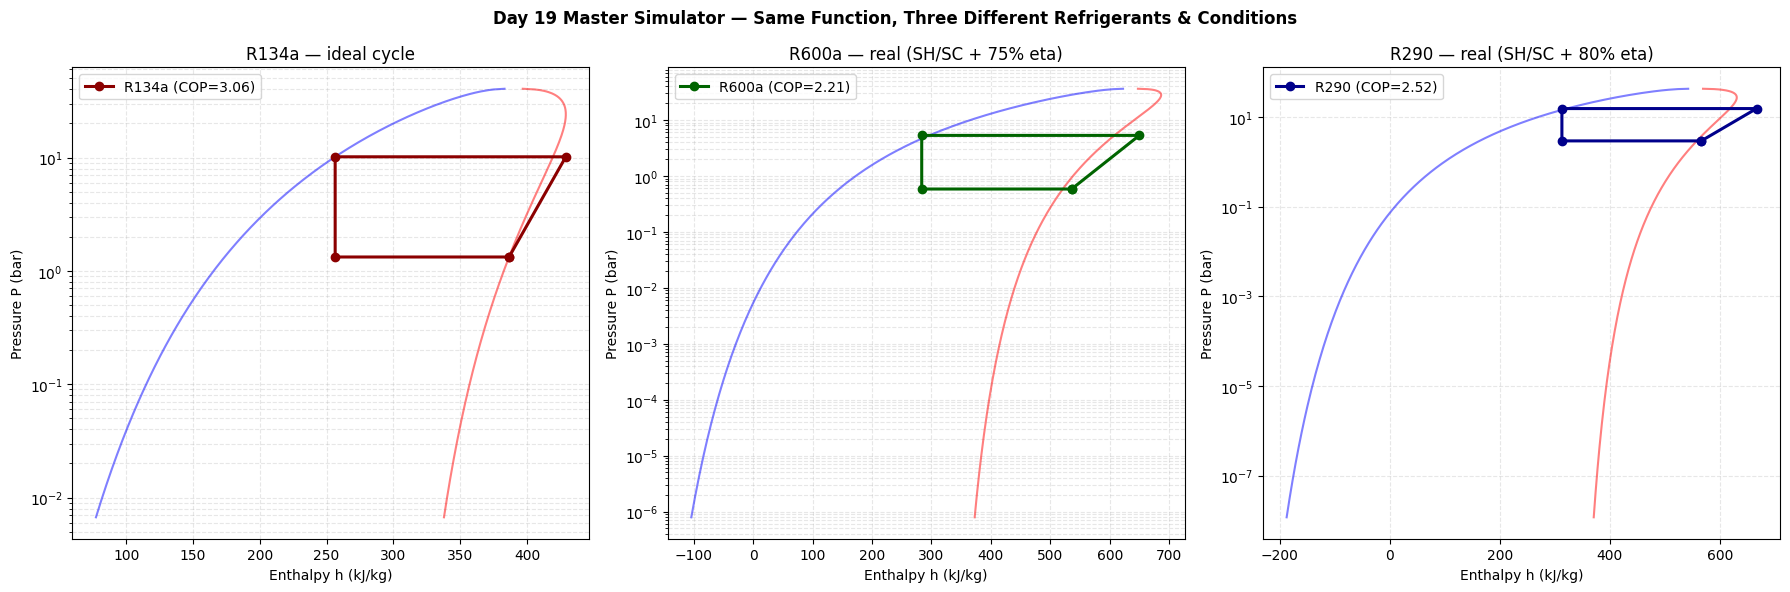

In [5]:
# CELL 5 — Reusable P-H diagram plotter — works for any of the scenarios above
def plot_cycle_on_ph(r, ax=None, color="black", show_dome=True):
    refrigerant = r["refrigerant"]
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6.5))

    if show_dome:
        T_min = CP.PropsSI("Tmin", refrigerant) + 5
        T_crit = CP.PropsSI("Tcrit", refrigerant) - 0.1
        T_range = np.linspace(T_min, T_crit, 300)
        h_liq = [CP.PropsSI("H", "T", T, "Q", 0, refrigerant) / 1000 for T in T_range]
        P_liq = [CP.PropsSI("P", "T", T, "Q", 0, refrigerant) / 1e5 for T in T_range]
        h_vap = [CP.PropsSI("H", "T", T, "Q", 1, refrigerant) / 1000 for T in T_range]
        P_vap = [CP.PropsSI("P", "T", T, "Q", 1, refrigerant) / 1e5 for T in T_range]
        ax.plot(h_liq, P_liq, "b-", linewidth=1.5, alpha=0.5)
        ax.plot(h_vap, P_vap, "r-", linewidth=1.5, alpha=0.5)

    P_evap_bar = r["P_evap"] / 1e5
    P_cond_bar = r["P_cond"] / 1e5
    cycle_h = [r["h1"]/1000, r["h2"]/1000, r["h3"]/1000, r["h4"]/1000, r["h1"]/1000]
    cycle_P = [P_evap_bar, P_cond_bar, P_cond_bar, P_evap_bar, P_evap_bar]
    ax.plot(cycle_h, cycle_P, "-", color=color, linewidth=2.2, marker="o", markersize=6,
            label=f"{refrigerant} (COP={r['COP']:.2f})")

    ax.set_yscale("log")
    ax.set_xlabel("Enthalpy h (kJ/kg)")
    ax.set_ylabel("Pressure P (bar)")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    return ax

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_cycle_on_ph(scenario_A, ax=axes[0], color="darkred")
axes[0].set_title("R134a — ideal cycle")
axes[0].legend()

plot_cycle_on_ph(scenario_B, ax=axes[1], color="darkgreen")
axes[1].set_title("R600a — real (SH/SC + 75% eta)")
axes[1].legend()

plot_cycle_on_ph(scenario_C, ax=axes[2], color="darkblue")
axes[2].set_title("R290 — real (SH/SC + 80% eta)")
axes[2].legend()

fig.suptitle("Day 19 Master Simulator — Same Function, Three Different Refrigerants & Conditions",
             fontweight="bold")
plt.tight_layout()
plt.savefig("day19_master_simulator.png", dpi=150)
plt.show()

**What this proves:** three completely different inputs — different refrigerants, different temperatures, different levels of real-world correction (ideal vs. 75%-efficient vs. 80%-efficient compressors) — all went through the **exact same function call**. That's the actual deliverable of Day 19: not a new simulation, but turning 18 days of one-off scripts into a single, general, reusable engineering tool. Anyone could now call `simulate_refrigeration_cycle("R32", -10, 50, superheat=8)` and get a complete, real-world-corrected cycle analysis back — no need to re-derive any of the thermodynamics by hand.

This is also the cleanest single artifact to point to in an interview: it demonstrates the full arc from Day 1 (reading one property) to Day 18 (regulatory compliance) compressed into one well-structured function.

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day19_refrigeration_simulator.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 19 - master combined refrigeration cycle simulator", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 19 - master combined refrigeration cycle simulator", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")
